# 

# Customer Segmentation

In [2]:
import numpy as np
import pandas as pd          # importing the libraries
import matplotlib.pyplot as plt
import seaborn as sns
import squarify

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
df=pd.read_excel("Desktop/IITB/Online Retail.xlsx")        # import the dataset

In [4]:
#read the first and last 5 rows of the dataset

print(df.head())
print(df.tail())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
       InvoiceNo StockCode                      Description  Quantity  \
541904    581587     22613      PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899     CHILDREN'S A

In [5]:
# summary statistics of continuous variables(unit price)

print(df['UnitPrice'].describe())

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64


 By the summary statistics we can show that that Inter Quartile Range(IQR) is so small ..most of the dataset is lying around 0

# Perform EDA

In [9]:
# manually check the categorical variable and put them in a cage

cat_columns = ["InvoiceNo","StockCode","Description" , "CustomerID","Country"]

# Analyse all the categorical variable

for i in cat_columns:
    print(f"\n{i}:")                         # In each column how many times the different category occurs
    print(df[i].value_counts())


InvoiceNo:
InvoiceNo
573585     1114
581219      749
581492      731
580729      721
558475      705
           ... 
554023        1
554022        1
554021        1
554020        1
C558901       1
Name: count, Length: 25900, dtype: int64

StockCode:
StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
          ... 
21431        1
22275        1
17001        1
90187A       1
72759        1
Name: count, Length: 4070, dtype: int64

Description:
Description
WHITE HANGING HEART T-LIGHT HOLDER     2369
REGENCY CAKESTAND 3 TIER               2200
JUMBO BAG RED RETROSPOT                2159
PARTY BUNTING                          1727
LUNCH BAG RED RETROSPOT                1638
                                       ... 
Missing                                   1
historic computer difference?....se       1
DUSTY PINK CHRISTMAS TREE 30CM            1
WRAP BLUE RUSSIAN FOLKART                 1
PINK BERTIE MOBILE PHONE CHARM            1
Name: count, Length: 422

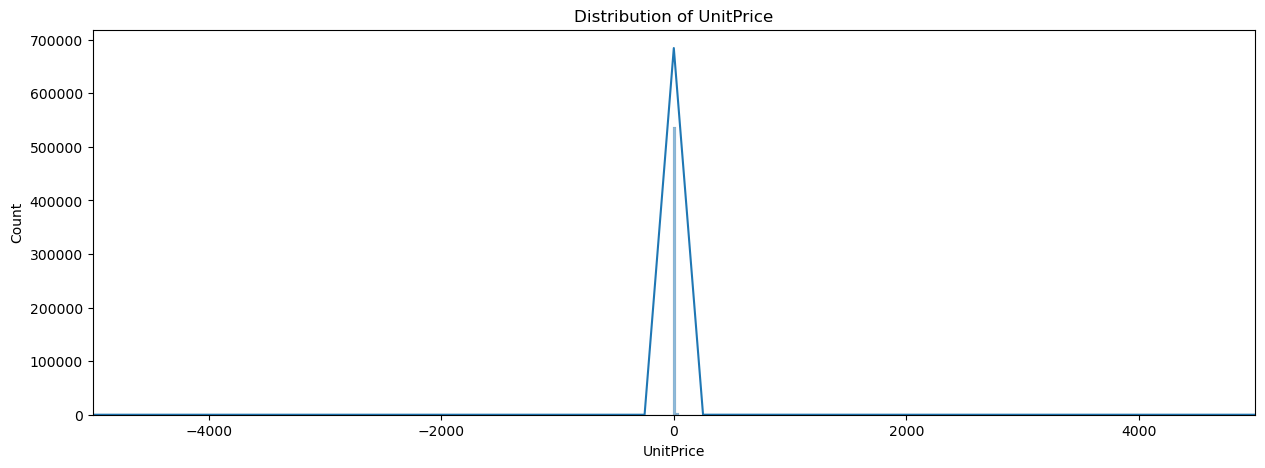

In [10]:
plt.figure(figsize=(15, 5))
sns.histplot(df["UnitPrice"], kde=True, bins=2000)
plt.title(f'Distribution of {"UnitPrice"}')
plt.xlim(-5000,5000)
plt.show()

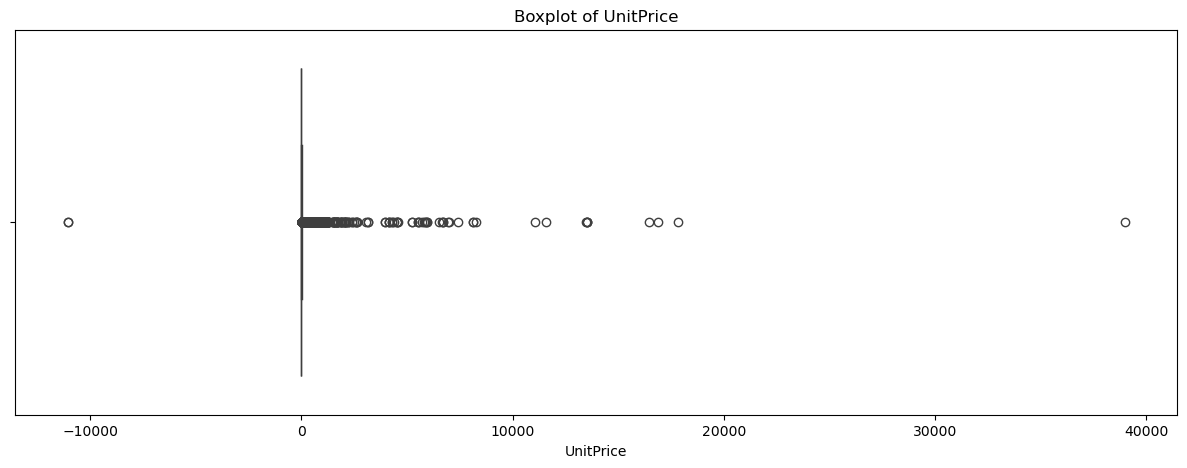

In [11]:
# using boxplot to detect the outlier of continious variables

plt.figure(figsize=(15, 5))
sns.boxplot(x=df["UnitPrice"])
plt.title(f'Boxplot of {"UnitPrice"}')
plt.show()

we can show that there are two outlier present

In [13]:
# Basic Preparation

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["UnitPrice"]


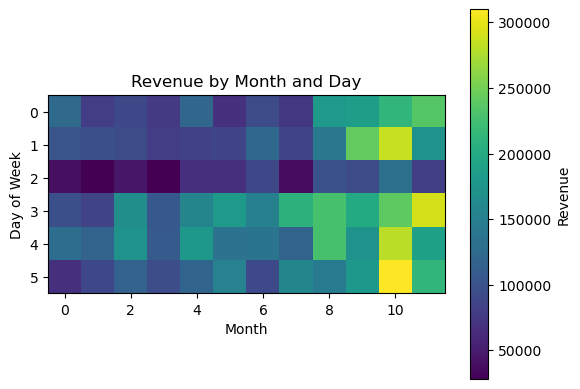

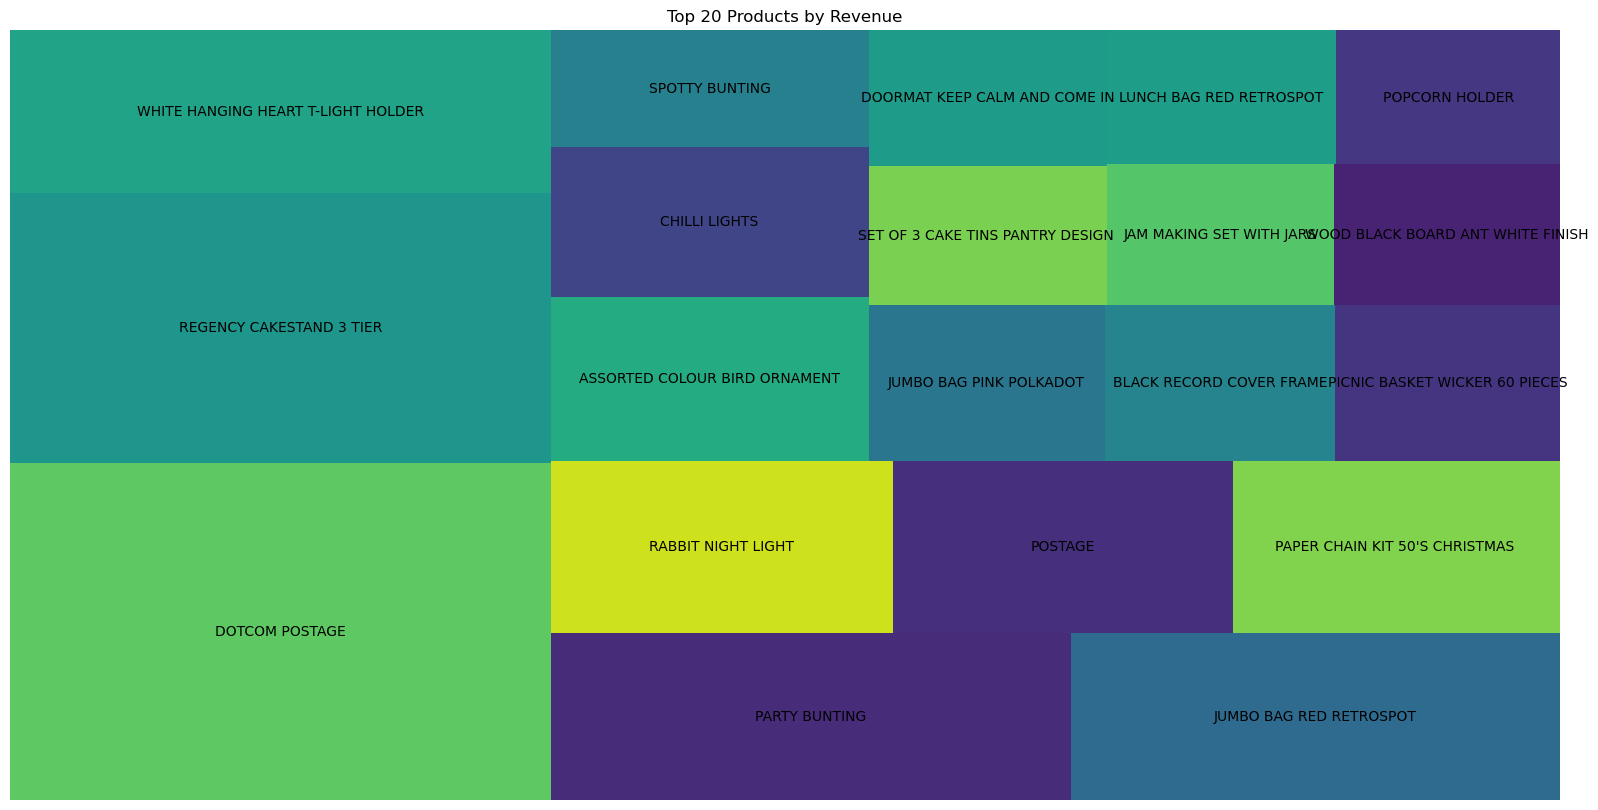

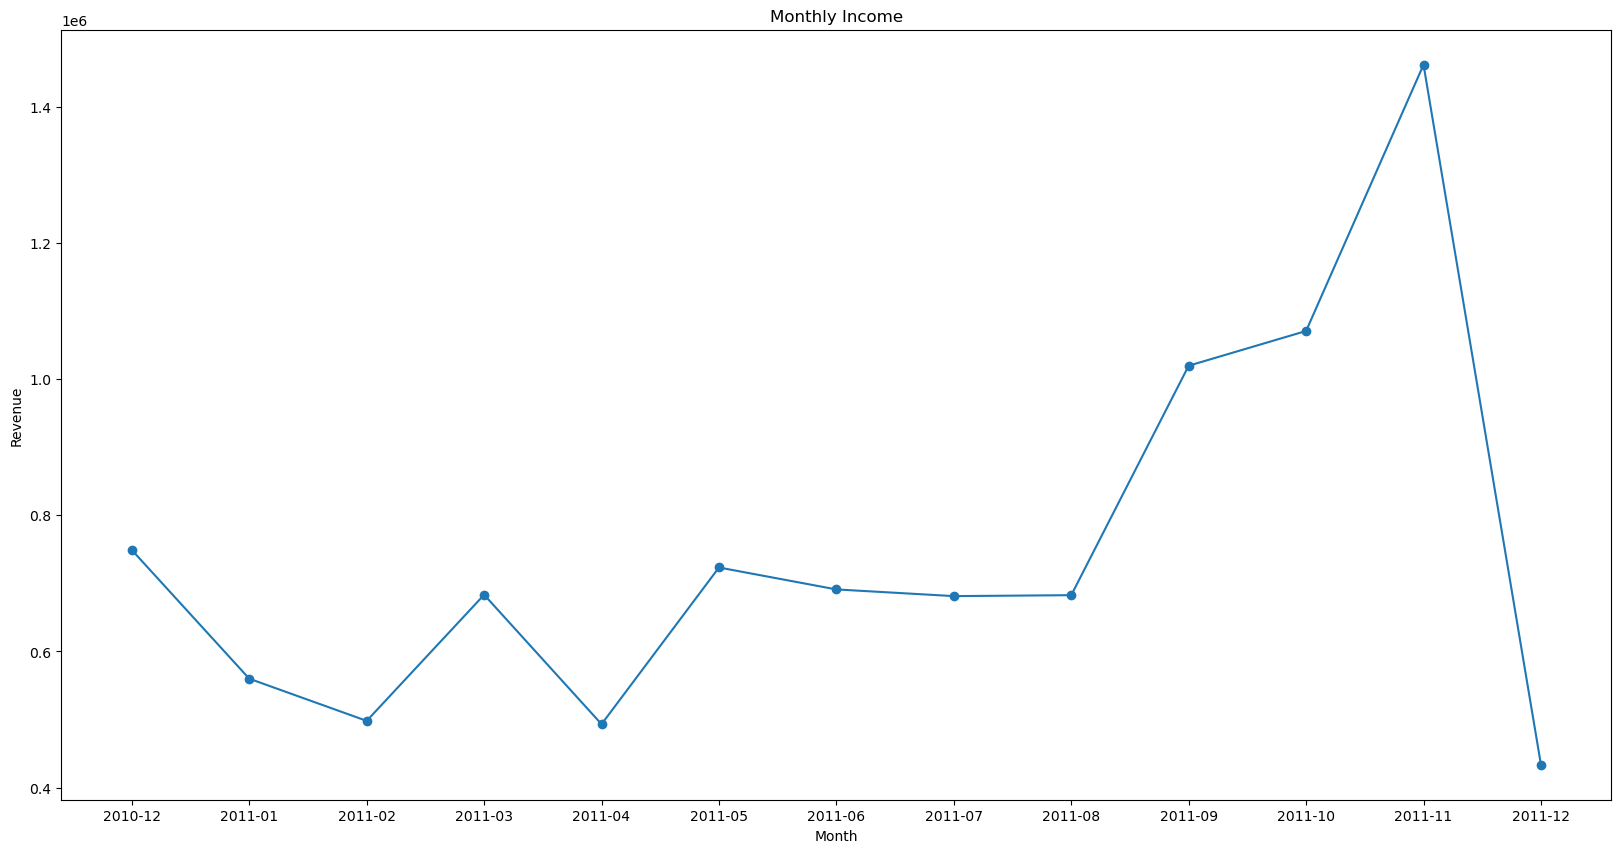

In [14]:
# plotting of heatmap which tell us  which day of which month the sale is high using the heat colour
# warm colour like yelllow,green indicate high sales and cold colour like blue, sky indicate low sale 




df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day_name()

table = df.pivot_table(
    values="Revenue",
    index="Day",
    columns="Month",
    aggfunc="sum"
)

plt.imshow(table)

plt.colorbar(label="Revenue")
plt.xlabel("Month")
plt.ylabel("Day of Week")
plt.title("Revenue by Month and Day")

plt.show()

 #   Using heat map we can show that the 11th month have highest sale and 



# use treemap to see the top 20 product from which the revenue is maximum






product_sales = df.groupby("Description")["Revenue"].sum()      #groupby is used to group the data using description of the product and count the total no of product sale

top20 = product_sales.sort_values(ascending=False).head(20)     # sort the data in decending order to get the product which has the maximum sale

plt.figure(figsize=(20,10))

squarify.plot(
    sizes=top20.values,
    label=top20.index
)

plt.title("Top 20 Products by Revenue")
plt.axis("off")

plt.show()






# How the sales change over time(Month)





monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum()            # group the revenue by the period month after month 

plt.figure(figsize=(20,10))
plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,                               # plot the revenue of each month and try to understand the sales over month
    marker = 'o'
)

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Income')
plt.show()




In [15]:
# Which Day has the maximum sales or day wise sale

daily_sales = df.groupby("Day")["Revenue"].sum()
print(daily_sales)

# product wise sale 

product_wise_sales = df.groupby("Description")["Revenue"].sum()
print(product_wise_sales.sort_values(ascending=False).head(20))

Day
Friday       1540610.811
Monday       1588609.431
Sunday        805678.891
Thursday     2112519.000
Tuesday      1966182.791
Wednesday    1734147.010
Name: Revenue, dtype: float64
Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
SPOTTY BUNTING                         42065.32
JUMBO BAG PINK POLKADOT                41619.66
BLACK RECORD COVER FRAME               40596.96
PICNIC BASKET WICKER 60 PIECES         39619.50
SET OF 3 CAKE TINS PANTRY DESIGN       37413.44
DOORMAT KEEP CALM AND COME IN          36565.39
JAM MAKING SET WITH JARS            

# Outlier Removal #

In [17]:
Q1 = df["UnitPrice"].quantile(0.25)
Q3 = df["UnitPrice"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 10 * IQR
upper_bound = Q3 + 10 * IQR

    # Filter out outliers
df = df[(df["UnitPrice"] >= lower_bound) & (df["UnitPrice"] <= upper_bound)]


In [28]:
print(df["UnitPrice"].describe())

count    539883.000000
mean          3.220573
std           3.335551
min           0.000000
25%           1.250000
50%           2.080000
75%           4.130000
max          32.690000
Name: UnitPrice, dtype: float64


In [30]:

# Future customer Spending Prediction Using Multiple Linear Regression


# Check Each and every column and clean the data on behalf of our goal
df = df.dropna(subset=["CustomerID"])   # Remove rows with missing Customer Ids
df = df.drop_duplicates()
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]  #  Here we only keep the rows where invoice no is not start with 'C'
df = df[df["Quantity"] > 0]              # Drop the row where 'Quanntity and 'UnitPrice' is positive
df = df[df["UnitPrice"] > 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [31]:

#Divide the data into Past and future so that we have y values in the training dataset


# Define cut-off point

cutoff_date = df['InvoiceDate'].max() - pd.Timedelta(days=30)     # TimeDelta creates a time duration of 60 days


In [34]:
# # Create the input features X values

past = df[df["InvoiceDate"] <= cutoff_date].copy()  # Among 12 months first 8 months spending declared as previous and next 4 months as future spending
future = df[df["InvoiceDate"] > cutoff_date].copy()

# # We take the features of X 'previous_spending' , 'total quantity order' , 'number of order' , 'number of different products'

# # Previous total Spending
# previous_spending = past.groupby("CustomerID")["Revenue"].sum()

# # Total quantity Oreder (previous)
# total_quantity = past.groupby("CustomerID")["Quantity"].sum()

# # How many number of time one customer order from (each 'invoiceNo' identify the individual order or Transaction)
# number_of_orders = past.groupby("CustomerID")["InvoiceNo"].nunique()

# # Number of diffwrent products order by any individual customer
# number_of_products = past.groupby("CustomerID")["StockCode"].nunique()

# # Combine each feature and crete a table with those feature
# features = pd.DataFrame({
#     "PreviousSpending": previous_spending,
#     "TotalQuantity" : total_quantity ,
#     "Number Of Orders" : number_of_orders * 100,
#     "NumberOfProducts" : number_of_products
# })

In [36]:
# The upgraded feature  forget the previous one


# Number of days since the customer last purchases ( recency = cutoffdate - last purchase date )
recency = (
    cutoff_date - past.groupby("CustomerID")["InvoiceDate"].max()
).dt.days

# number of unique invoices per customer

frequency = past.groupby("CustomerID")["InvoiceNo"].nunique()

# Previous Spending

previous_spending = past.groupby("CustomerID")["Revenue"].sum()

# Average order value

avg_order_value = previous_spending / frequency 

# combine the features

features = pd.DataFrame({
    "Recency": recency,
    "Frequency" : frequency * 100,
    "Previous Spending" : previous_spending,
    "Average order Value" : avg_order_value
})


In [38]:
#  Create the target variable or Y values

target = future.groupby("CustomerID")["Revenue"].sum()
target = target.rename("FutureSpending")     # The variable will be target but the series name is that if i call target.name() then it appear

# Combine the input and the target variable

data = features.join(target , how ='left')

data["FutureSpending"] = data["FutureSpending"].fillna(0)           # customers who did not appeared in future are considered as 0 spending in future
print(data.tail())


            Recency  Frequency  Previous Spending  Average order Value  \
CustomerID                                                               
18280.0         247        100             180.60           180.600000   
18281.0         150        100              80.82            80.820000   
18282.0          95        100             100.21           100.210000   
18283.0          12       1100            1199.82           109.074545   
18287.0          12        300            1837.28           612.426667   

            FutureSpending  
CustomerID                  
18280.0               0.00  
18281.0               0.00  
18282.0              77.84  
18283.0             845.71  
18287.0               0.00  


In [40]:

# Seperate out the input and output feature

X = data.drop(columns=["FutureSpending"])
y = data["FutureSpending"]


# Split the dataset into Training and Testing proportion

In [43]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test =train_test_split(
    X , y , test_size = 0.2 , random_state = 42
)

In [45]:
#  Train and Fit the model

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train , y_train)

LinearRegression()

In [47]:
# prdiction using X_test values

predictions = model.predict(X_test)

In [49]:
# Root Mean Square Error

from sklearn.metrics import mean_squared_error 

rmse = mean_squared_error(y_test , predictions)
print(rmse ** 0.5)

565.7663009112467


In [51]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test ,predictions )
print(r2)


0.6794882583667263


In [53]:
print("Intercept : ", model.intercept_,
     model.coef_)

Intercept :  -5.174206965934047 [ 0.47387734  0.37757802  0.08758264 -0.08820647]


In [55]:
df["date"] = pd.to_datetime(df["InvoiceDate"]).dt.date

In [57]:
from statsmodels.tsa.seasonal import seasonal_decompose
daily_sales = df.groupby("date")["Quantity"].sum()
len(daily_sales)

305

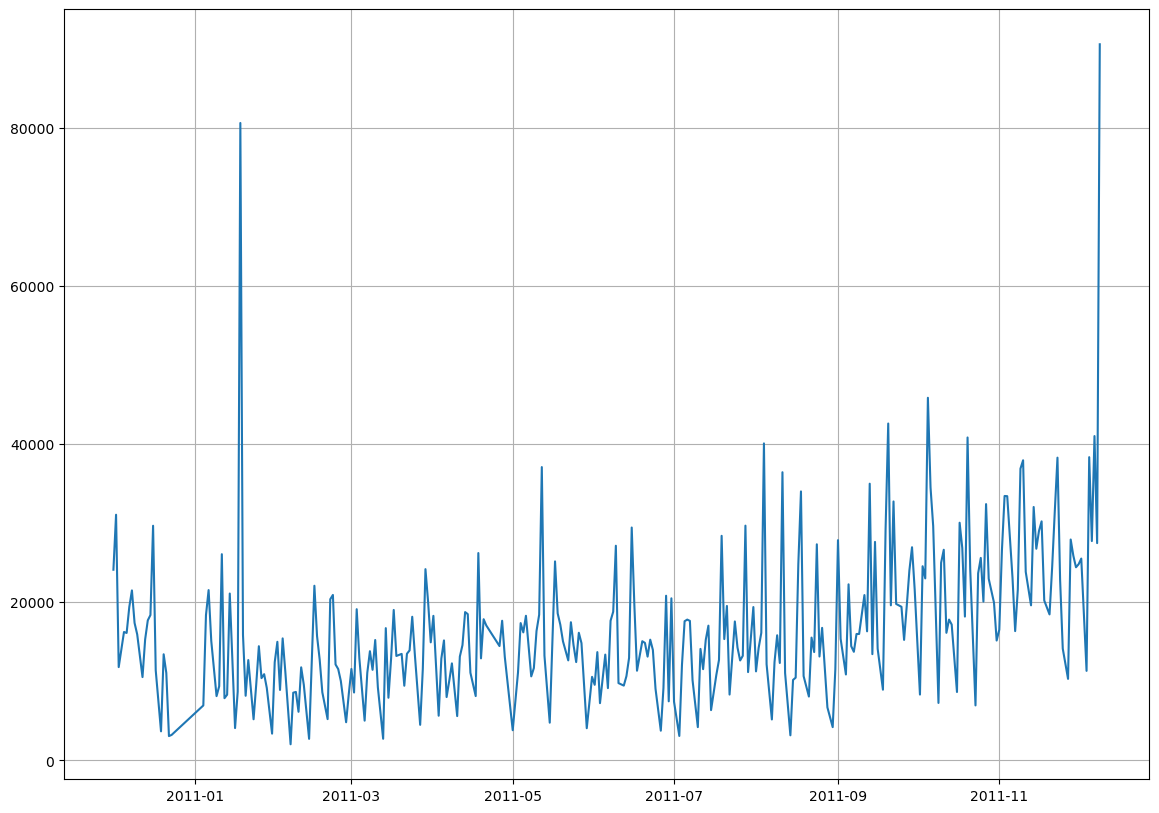

In [59]:
plt.figure(figsize=(14,10))
plt.plot(daily_sales.index , daily_sales )
plt.grid(True)

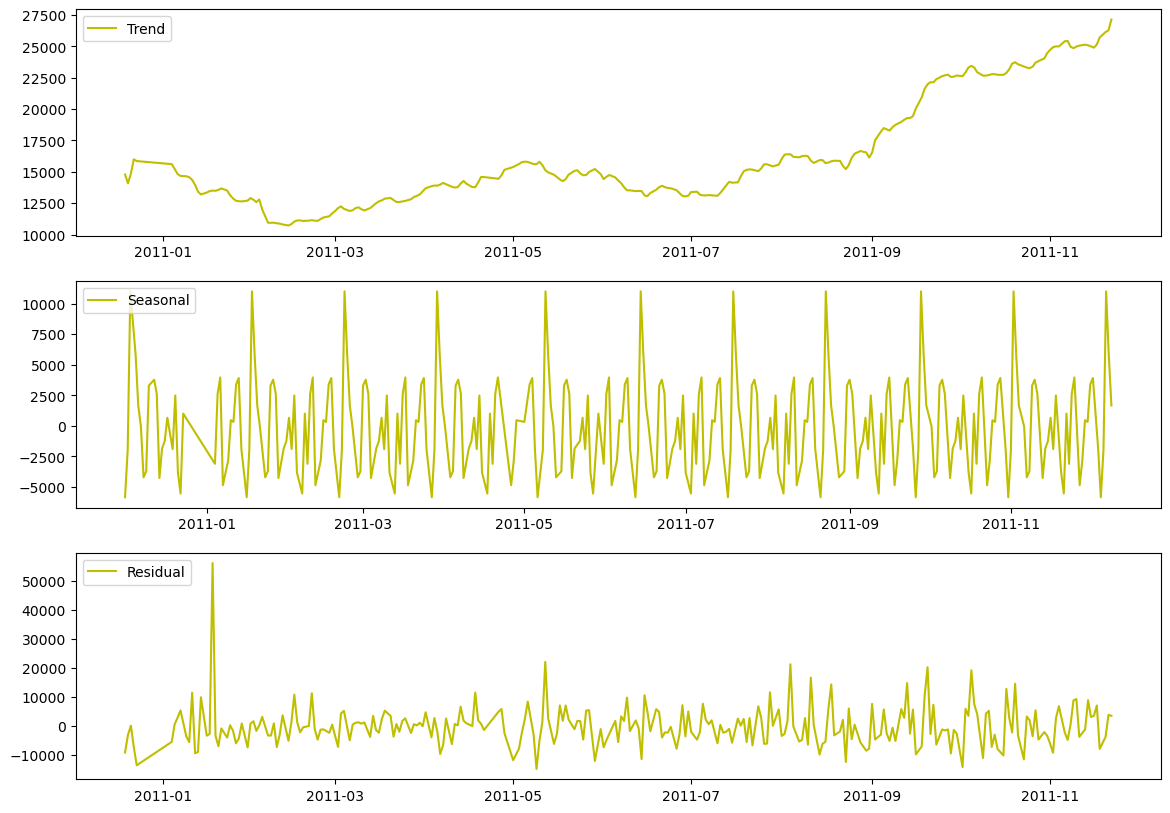

In [61]:
decomposition_additive = seasonal_decompose( daily_sales , model = "additive" , period = 30 )

trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

plt.figure(figsize=(14,10))
plt.subplot(3 , 1 , 1)
plt.plot(trend_additive , label = 'Trend' , color = 'y')
plt.legend(loc = 'upper left')

plt.subplot(3 , 1 , 2)
plt.plot(seasonal_additive , label = 'Seasonal' , color = 'y')
plt.legend(loc = 'upper left')

plt.subplot(3 , 1 , 3)
plt.plot(residual_additive , label = 'Residual' , color = 'y')
plt.legend(loc = 'upper left')

## Customer Segmentation .... Clustering the customer into type of customer depending into their behaviour

In [64]:
# Creating the features Recency  ,  Frequency  , Monetary

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)      # create a referrence date so that we can calculate how many dsys before
# the customer purchase

features = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
)

print(features.head())
print(features.describe())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1437.24
12349.0          19          1   1417.60
12350.0         310          1    294.40
           Recency    Frequency       Monetary
count  4331.000000  4331.000000    4331.000000
mean     92.577003     4.256061    2009.215083
std     100.070300     7.651005    8883.841842
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     302.050000
50%      51.000000     2.000000     661.320000
75%     143.000000     5.000000    1637.450000
max     374.000000   206.000000  279417.220000


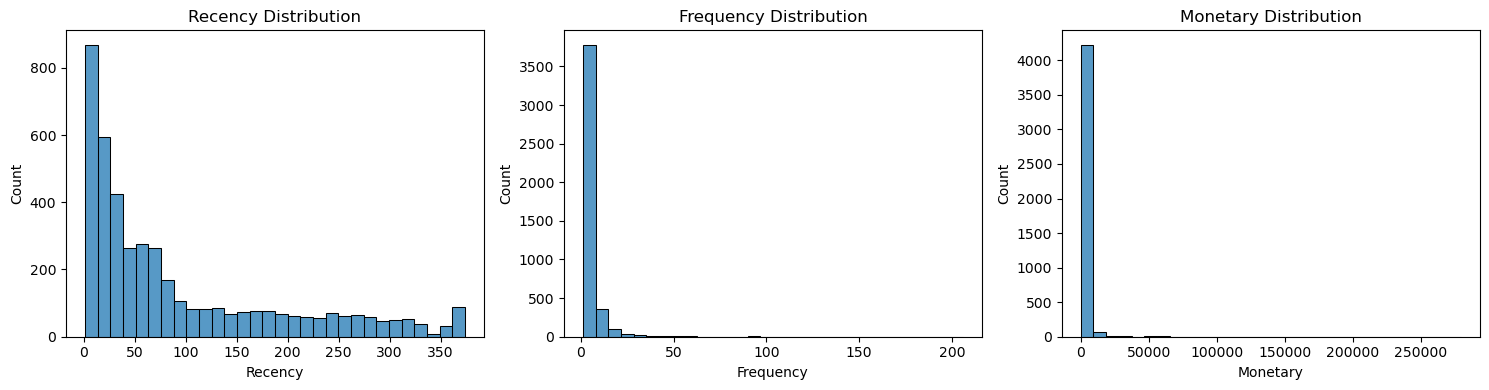

In [66]:
# Before clustering explore the features

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(features["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(features["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(features["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [68]:
# Each of the 3 features are right skewed  apply log transformation to compress the large value and the standardized them so that all of them
#come into same scale

features_model = features[["Recency", "Frequency", "Monetary"]].copy()

# Reduce right-skewness
features_log = np.log1p(features_model)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_log)

print("Scaled data shape:", X_scaled.shape)

# X_scaled return a numpy array so convert it into panda dataframe
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features.columns,
    index=features.index
)

Scaled data shape: (4331, 3)


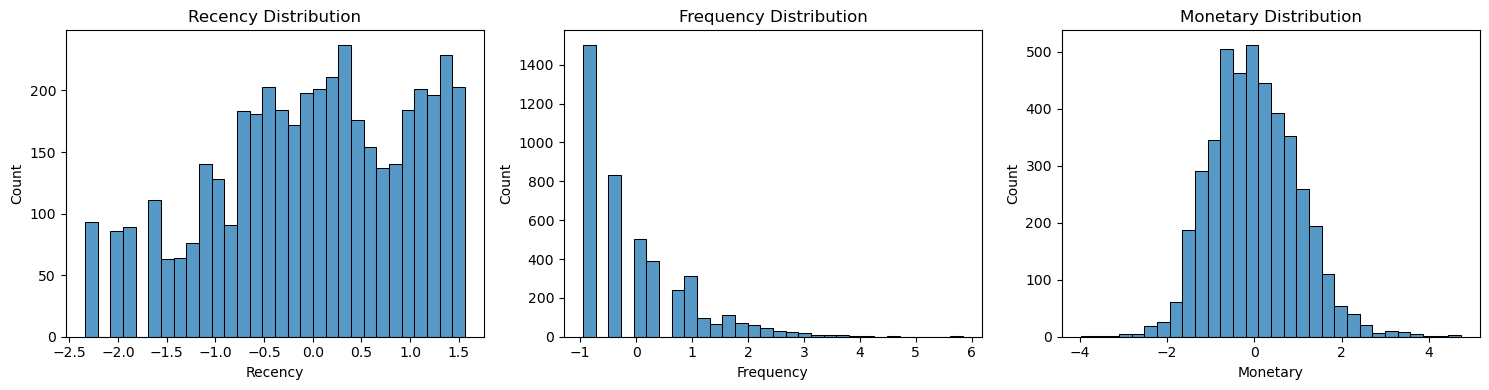

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(X_scaled["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(X_scaled["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(X_scaled["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [72]:
# by comparing different values of k(no of cluster) we should check the "INERTIA" (total squared distance between customers and their assigned
# cluster center) and silhouette score(how close each customer is close to their own cluster compared to other)


inertia = []
silhouette_scores = []
k_values = range(2, 15)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

print(results)

     K      Inertia  Silhouette Score
0    2  6471.872062          0.432758
1    3  4854.788539          0.340283
2    4  3929.641513          0.336231
3    5  3285.587727          0.316223
4    6  2850.014484          0.312763
5    7  2543.824312          0.309177
6    8  2337.903371          0.286382
7    9  2152.923783          0.280547
8   10  1995.089117          0.278302
9   11  1876.900068          0.270376
10  12  1765.534722          0.270470
11  13  1670.617093          0.271039
12  14  1577.797524          0.276957


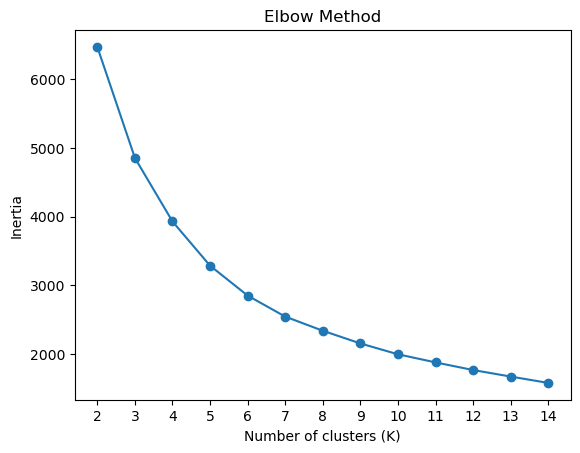

In [73]:
# Elbow Method

plt.plot(list(k_values), inertia, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.show()


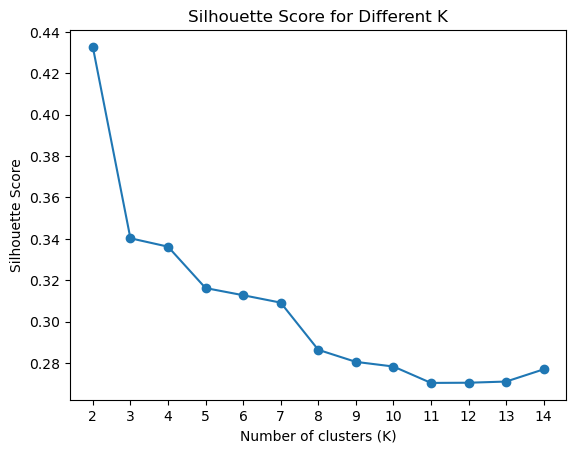

In [74]:
# silhouette score vs number of cluster

plt.plot(list(k_values), silhouette_scores, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")
plt.xticks(list(k_values))
plt.show()

# by looking at silhouette score and inertia plot we can conclude that high silhouette score as well as minimum inertia is required and we got
# it on k= 4

In [75]:

# after examine the two plot we came to the conclusion that k=4 is best fitted

best_k = 4

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

features["Cluster"] = kmeans.fit_predict(X_scaled)

print(features.head())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        1
12347.0           2          7   4310.00        2
12348.0          75          4   1437.24        1
12349.0          19          1   1417.60        0
12350.0         310          1    294.40        3


Cluster
0     841
1    1174
2     719
3    1597
Name: count, dtype: int64


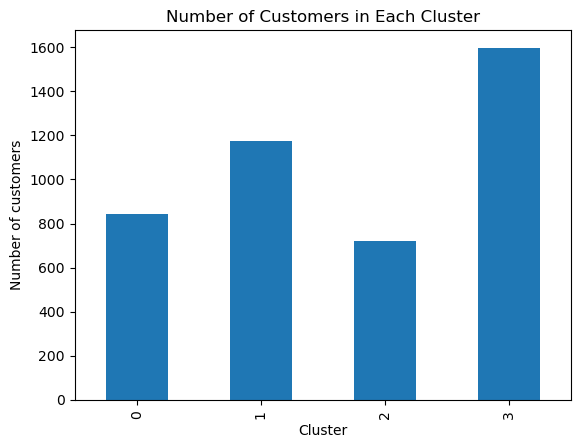

In [76]:

# Examine the customer groups .. how many customers are in each group

cluster_counts = features["Cluster"].value_counts().sort_index()

print(cluster_counts)

cluster_counts.plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Number of customers")
plt.title("Number of Customers in Each Cluster")
plt.show()

In [77]:
# Calculate the average features values within each other
# distiguish between the cluster

cluster_profile = features.groupby("Cluster").agg(
    Customers=("Recency", "size"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Median_Recency=("Recency", "median"),
    Median_Frequency=("Frequency", "median"),
    Median_Monetary=("Monetary", "median")
).round(2)

print(cluster_profile)

         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Median_Recency  \
Cluster                                                                        
0              841        19.05           2.06        521.74            18.0   
1             1174        69.13           4.09       1736.40            54.0   
2              719        11.91          13.61       7900.00             8.0   
3             1597       184.85           1.32        340.95           179.0   

         Median_Frequency  Median_Monetary  
Cluster                                     
0                     2.0           446.94  
1                     4.0          1335.76  
2                    10.0          3659.61  
3                     1.0           290.40  


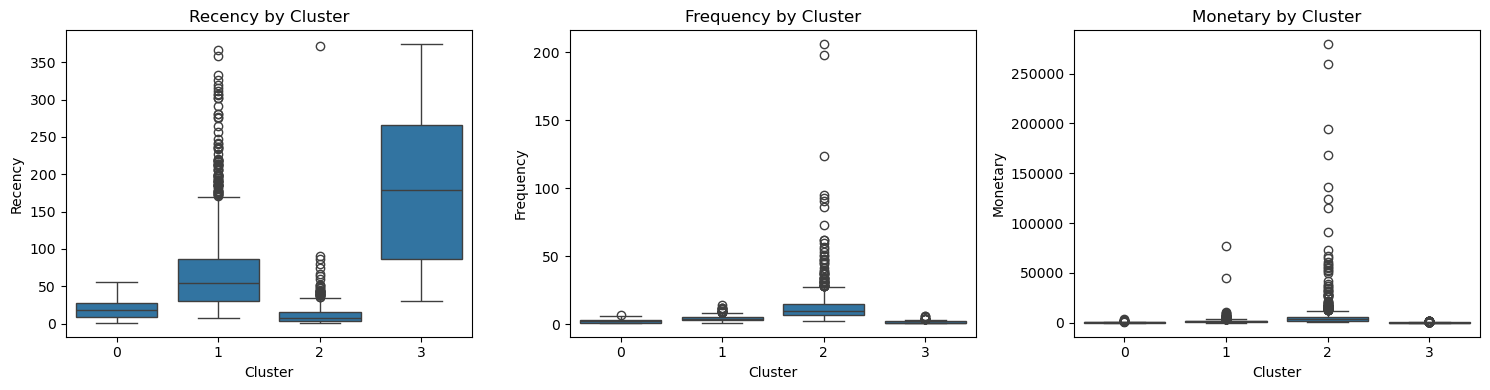

In [78]:
# visualize the cluster profiles


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=features, x="Cluster", y="Recency", ax=axes[0])
axes[0].set_title("Recency by Cluster")

sns.boxplot(data=features, x="Cluster", y="Frequency", ax=axes[1])
axes[1].set_title("Frequency by Cluster")

sns.boxplot(data=features, x="Cluster", y="Monetary", ax=axes[2])
axes[2].set_title("Monetary by Cluster")

plt.tight_layout()
plt.show()

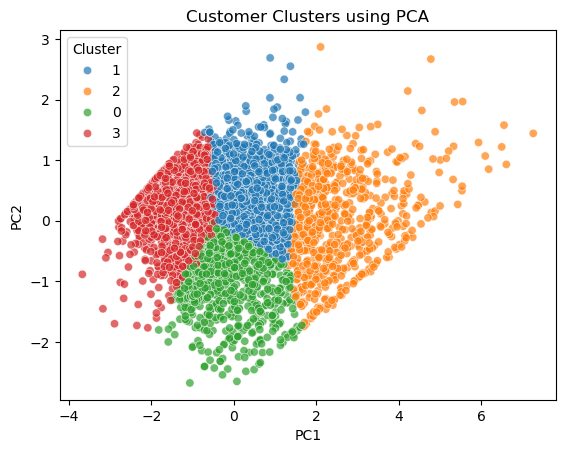

Variance explained by two components: 0.938


In [79]:

# performing PCA to visualize the 3 features data into 2 dimension to understand cluster well

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plot_data = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": features["Cluster"].astype(str).values
})

sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)

plt.title("Customer Clusters using PCA")
plt.show()

print(
    "Variance explained by two components:",
    pca.explained_variance_ratio_.sum().round(3)
)

In [87]:
features.to_csv("customer_segments.csv")

cluster_profile.to_csv("cluster_profile.csv")

In [90]:
import os
print(os.getcwd())

/Users/kuldipnandi


# Repeat purchase prediction using classification

In [93]:
 # import library

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


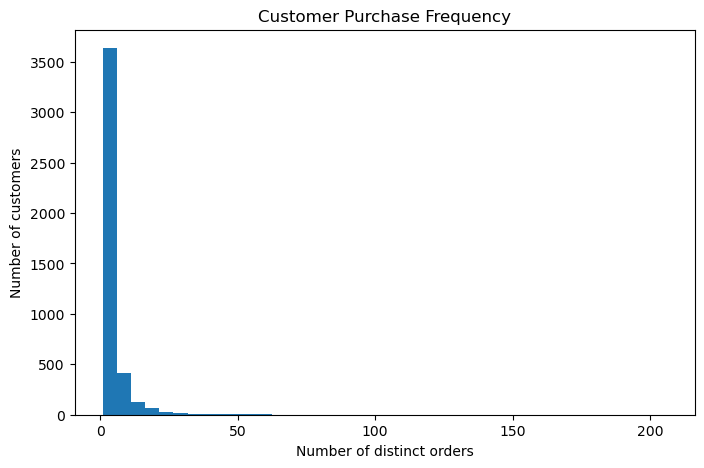

In [95]:
# explore customer purchase frequency

customer_orders = df.groupby("CustomerID")["InvoiceNo"].nunique()

plt.figure(figsize=(8, 5))
plt.hist(customer_orders, bins=40)
plt.xlabel("Number of distinct orders")
plt.ylabel("Number of customers")
plt.title("Customer Purchase Frequency")
plt.show()

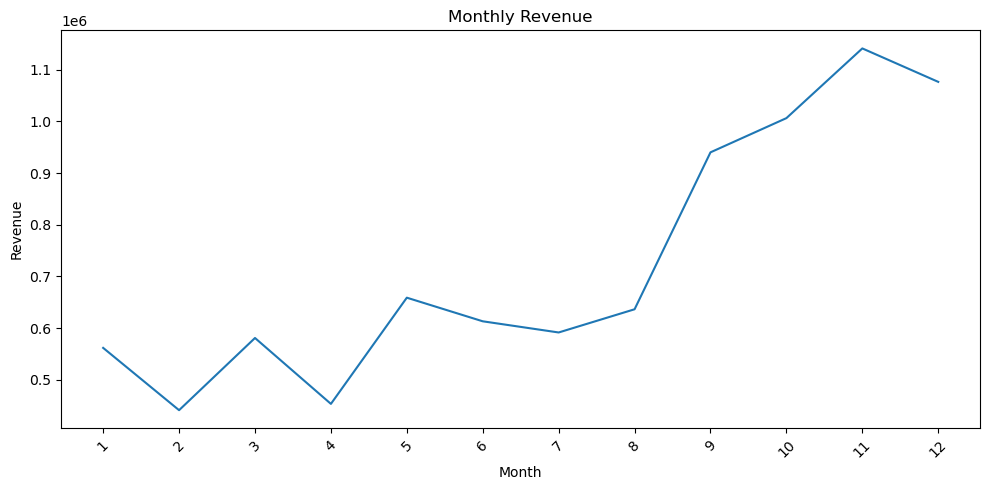

In [97]:
# Explore monthly revenue


monthly_revenue = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [99]:
#Customer level input features

reference_date = cutoff_date + pd.Timedelta(days=1)

features = past.groupby("CustomerID").agg(
    Recency=(
        "InvoiceDate",
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
    TotalQuantity=("Quantity", "sum"),
    ProductDiversity=("StockCode", "nunique")
)

features["AverageOrderValue"] = (
    features["Monetary"] / features["Frequency"]
)

print(features.head())

            Recency  Frequency  Monetary  TotalQuantity  ProductDiversity  \
CustomerID                                                                  
12346.0         296          1  77183.60          74215                 1   
12347.0          10          6   4085.18           2266               100   
12348.0          45          4   1437.24           2332                21   
12350.0         280          1    294.40            196                16   
12352.0           6          7   1385.74            526                57   

            AverageOrderValue  
CustomerID                     
12346.0          77183.600000  
12347.0            680.863333  
12348.0            359.310000  
12350.0            294.400000  
12352.0            197.962857  


In [101]:
# count each customer's distinct invoices  in the future period

future_orders = future.groupby("CustomerID")["InvoiceNo"].nunique()

target = (
    future_orders
    .gt(0)
    .astype(int)
    .rename("WillPurchase")
)

In [103]:
#combine the input features and target

data = features.join(target, how="left")            # here the "left join" means those customer id appeared who are present in features not 
                                                    # only on target 

# Customers with no recorded future purchase get target 0
data["WillPurchase"] = data["WillPurchase"].fillna(0).astype(int)

print(data.head())
print(data["WillPurchase"].value_counts())

            Recency  Frequency  Monetary  TotalQuantity  ProductDiversity  \
CustomerID                                                                  
12346.0         296          1  77183.60          74215                 1   
12347.0          10          6   4085.18           2266               100   
12348.0          45          4   1437.24           2332                21   
12350.0         280          1    294.40            196                16   
12352.0           6          7   1385.74            526                57   

            AverageOrderValue  WillPurchase  
CustomerID                                   
12346.0          77183.600000             0  
12347.0            680.863333             1  
12348.0            359.310000             0  
12350.0            294.400000             0  
12352.0            197.962857             0  
WillPurchase
0    2685
1    1379
Name: count, dtype: int64


In [105]:
class_counts = data["WillPurchase"].value_counts().sort_index()

print(class_counts)
print("Class proportions:")
print(data["WillPurchase"].value_counts(normalize=True))

WillPurchase
0    2685
1    1379
Name: count, dtype: int64
Class proportions:
WillPurchase
0    0.660679
1    0.339321
Name: proportion, dtype: float64


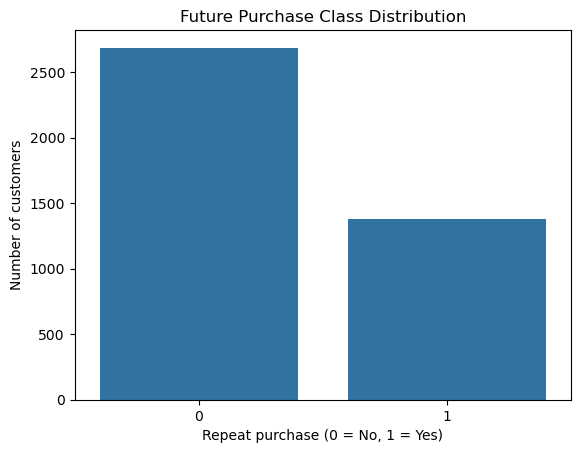

In [107]:
# check the class balance if one category is different from another

sns.countplot(data=data, x="WillPurchase")

plt.xlabel("Repeat purchase (0 = No, 1 = Yes)")
plt.ylabel("Number of customers")
plt.title("Future Purchase Class Distribution")
plt.show()

In [109]:
# seperate input features and target data

X = data.drop(columns=["WillPurchase"])
y = data["WillPurchase"]

print("Input features:", X.columns.tolist())
print("Target:", y.name)

Input features: ['Recency', 'Frequency', 'Monetary', 'TotalQuantity', 'ProductDiversity', 'AverageOrderValue']
Target: WillPurchase


In [111]:
# split into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training customers:", len(X_train))
print("Testing customers:", len(X_test))

Training customers: 3251
Testing customers: 813


In [113]:
# fit the logistic regression and estimate the probability that a customer purchase again

logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

In [115]:
# use random forest which train many decision trees and combine their prediction

forest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)
forest_probabilities = forest_model.predict_proba(X_test)[:, 1]

In [117]:
# Evaluate the models through  "Accuracy" , "Precision" , "Recall" , "F1-Score" , "ROC_AUC"

def evaluate_model(name, y_true, predictions, probabilities):
    print("\n", name)
    print("-" * 40)

    print("Accuracy:",
          round(accuracy_score(y_true, predictions), 3))

    print("Precision:",
          round(precision_score(
              y_true, predictions, zero_division=0
          ), 3))

    print("Recall:",
          round(recall_score(
              y_true, predictions, zero_division=0
          ), 3))

    print("F1-score:",
          round(f1_score(
              y_true, predictions, zero_division=0
          ), 3))

    print("ROC-AUC:",
          round(roc_auc_score(y_true, probabilities), 3))

    print("\nClassification report:")
    print(classification_report(
        y_true, predictions, zero_division=0
    ))


evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_predictions,
    logistic_probabilities
)

evaluate_model(
    "Random Forest",
    y_test,
    forest_predictions,
    forest_probabilities
)


 Logistic Regression
----------------------------------------
Accuracy: 0.716
Precision: 0.578
Recall: 0.605
F1-score: 0.591
ROC-AUC: 0.739

Classification report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       537
           1       0.58      0.61      0.59       276

    accuracy                           0.72       813
   macro avg       0.68      0.69      0.69       813
weighted avg       0.72      0.72      0.72       813


 Random Forest
----------------------------------------
Accuracy: 0.707
Precision: 0.577
Recall: 0.518
F1-score: 0.546
ROC-AUC: 0.735

Classification report:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       537
           1       0.58      0.52      0.55       276

    accuracy                           0.71       813
   macro avg       0.67      0.66      0.66       813
weighted avg       0.70      0.71      0.70       813



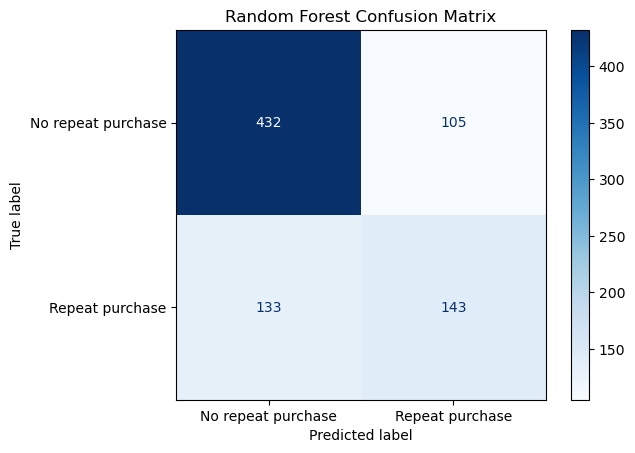

In [119]:
# as it is a low risk marketing application and in a real world data we considered as this values are good and two modeles are well fitted

# "CONFUSION MATRIX"   a confusion matrix shows the types of correct and incorrect predictions

ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_predictions,
    display_labels=["No repeat purchase", "Repeat purchase"],
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

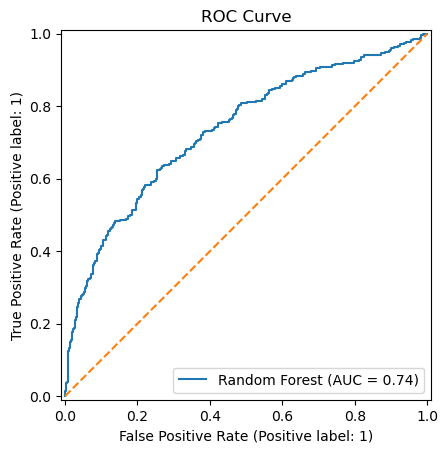

In [121]:
# Roc curve

RocCurveDisplay.from_predictions(
    y_test,
    forest_probabilities,
    name="Random Forest"
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.show()

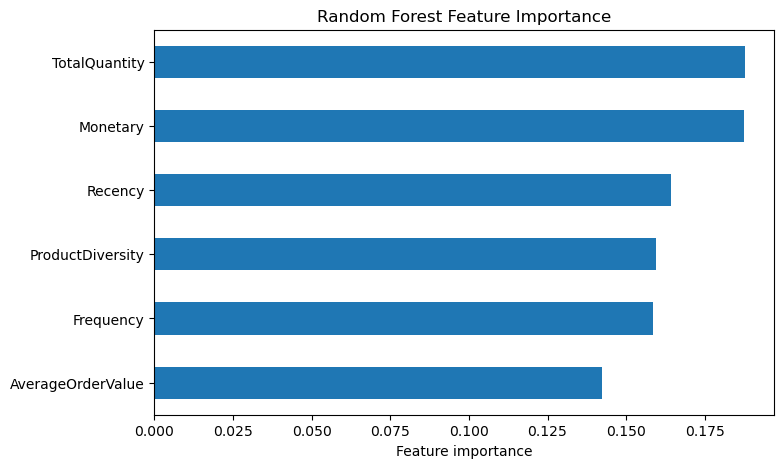

In [123]:
# plot feature importance in "Random Forest" these indicate how much the model relied on each features when making splits

rf = forest_model.named_steps["model"]

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values()

importance.plot(kind="barh", figsize=(8, 5))

plt.xlabel("Feature importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [125]:
# by looking at the above plot we can say that customers who spent more money(monetary) ,ordered greater quantity of product and purchased 
# more recently were more likely to purchase again during the future period

from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

print(
    "Baseline accuracy:",
    accuracy_score(y_test, baseline_predictions)
)

Baseline accuracy: 0.6605166051660517
